In [ ]:
%pip install -q tsfel


# Tugas 3 – Preprocessing Data dan Ekstraksi Fitur TSFEL


**Studi Kasus:** Analisis Carbon Monoxide (CO)  
**Wilayah:** Kecamatan Klampis

## Penjelasan

Tugas ini melakukan preprocessing dan ekstraksi fitur pada data konsentrasi
Carbon Monoxide (CO) di Kecamatan Klampis, Kabupaten Bangkalan.

Tahapan yang dilakukan meliputi pembentukan data menjadi 365 hari,
penanganan missing value, identifikasi dan perbaikan outlier, kemudian
ekstraksi fitur menggunakan Time Series Feature Extraction Library (TSFEL).

In [4]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Library berhasil di-import.")

Library berhasil di-import.


##Dataset

In [5]:
# ============================================================
# MEMBACA DATASET
# ============================================================

file_path = "Sentinel-5P_CO-CO_VISUALIZED-2025-02-20T00_00_00_000Z-2026-02-20T23_59_59_999Z.csv"

df_co = pd.read_csv(file_path)

# Mengubah tanggal
df_co["tanggal"] = pd.to_datetime(
    df_co["C0/date"],
    utc=True
).dt.date

# Mengambil tanggal dan nilai CO
df_co = df_co[["tanggal", "C0/mean"]].copy()

# Mengubah nama kolom
df_co.columns = ["tanggal", "CO"]

# Memastikan CO berupa numerik
df_co["CO"] = pd.to_numeric(
    df_co["CO"],
    errors="coerce"
)

# Mengurutkan berdasarkan tanggal
df_co = df_co.sort_values("tanggal").reset_index(drop=True)

print("Jumlah data asli :", len(df_co))
print("Tanggal awal     :", df_co["tanggal"].min())
print("Tanggal akhir    :", df_co["tanggal"].max())
print("Missing CO awal  :", df_co["CO"].isna().sum())

display(df_co.head())

Jumlah data asli : 198
Tanggal awal     : 2025-02-21
Tanggal akhir    : 2026-02-20
Missing CO awal  : 0


,tanggal,CO
0,2025-02-21,0.031969
1,2025-02-28,0.028443
2,2025-03-01,0.032531
3,2025-03-02,0.031356
4,2025-03-03,0.029649


##Membentuk Data 365 Hari

In [6]:
# ============================================================
# MEMBENTUK DATA 365 HARI
# ============================================================

tanggal_lengkap = pd.date_range(
    start="2025-02-21",
    periods=365,
    freq="D"
)

df_365 = pd.DataFrame({
    "tanggal": tanggal_lengkap.date
})

# Gabungkan dengan data asli
df_365 = df_365.merge(
    df_co[["tanggal", "CO"]],
    on="tanggal",
    how="left"
)

print("Tanggal awal :", df_365["tanggal"].min())
print("Tanggal akhir:", df_365["tanggal"].max())
print("Jumlah hari  :", len(df_365))

display(df_365.head(10))

Tanggal awal : 2025-02-21
Tanggal akhir: 2026-02-20
Jumlah hari  : 366


,tanggal,CO
0,2025-02-21,0.031969
1,2025-02-22,NaN
2,2025-02-23,NaN
3,2025-02-24,NaN
4,2025-02-25,NaN
5,2025-02-26,NaN
6,2025-02-27,NaN
7,2025-02-28,0.028443
8,2025-03-01,0.032531
9,2025-03-02,0.031356


In [7]:
# ============================================================
# PENANGANAN MISSING VALUE
# ============================================================

missing_sebelum = df_365["CO"].isna().sum()

# Simpan data sebelum imputasi
df_sebelum_imputasi = df_365.copy()

# Imputasi menggunakan interpolasi linear
df_365["CO"] = df_365["CO"].interpolate(
    method="linear"
)

# Jika masih ada missing di ujung data,
# gunakan forward/backward fill sebagai pengaman
df_365["CO"] = df_365["CO"].ffill().bfill()

missing_sesudah = df_365["CO"].isna().sum()

print("Missing sebelum imputasi :", missing_sebelum)
print("Missing sesudah imputasi :", missing_sesudah)

display(df_365.head(10))

Missing sebelum imputasi : 168
Missing sesudah imputasi : 0


,tanggal,CO
0,2025-02-21,0.031969
1,2025-02-22,0.031465
2,2025-02-23,0.030961
3,2025-02-24,0.030458
4,2025-02-25,0.029954
5,2025-02-26,0.029450
6,2025-02-27,0.028947
7,2025-02-28,0.028443
8,2025-03-01,0.032531
9,2025-03-02,0.031356


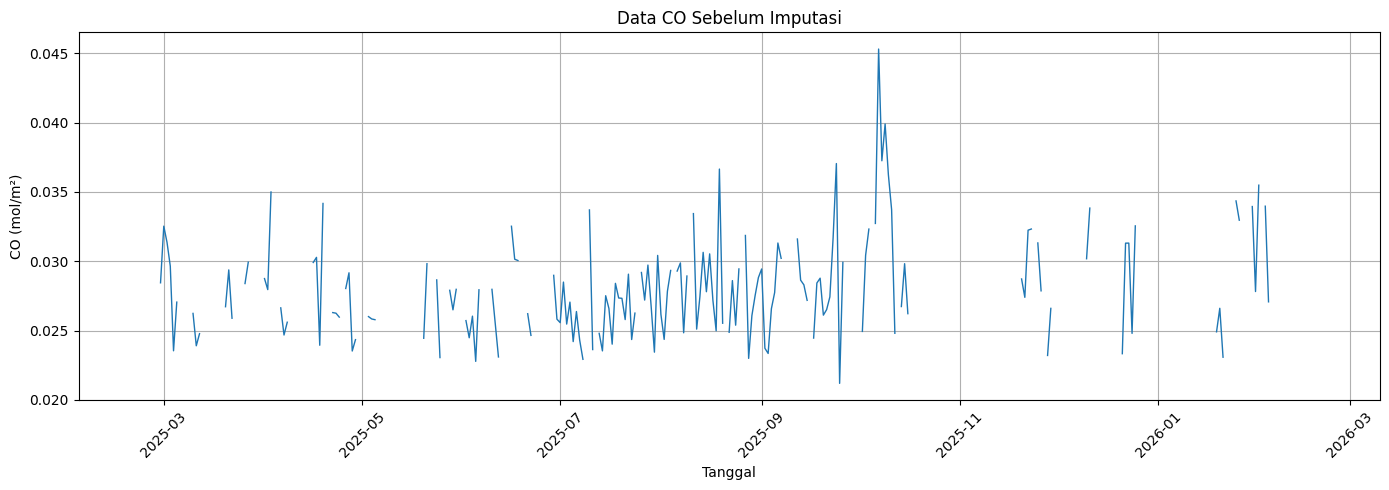

In [8]:
# ============================================================
# VISUALISASI SEBELUM IMPUTASI
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    pd.to_datetime(df_sebelum_imputasi["tanggal"]),
    df_sebelum_imputasi["CO"],
    linewidth=1
)

plt.title("Data CO Sebelum Imputasi")
plt.xlabel("Tanggal")
plt.ylabel("CO (mol/m²)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# IDENTIFIKASI OUTLIER DENGAN METODE IQR
# ============================================================

Q1 = df_365["CO"].quantile(0.25)
Q3 = df_365["CO"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

df_365["outlier"] = (
    (df_365["CO"] < batas_bawah) |
    (df_365["CO"] > batas_atas)
)

jumlah_outlier = df_365["outlier"].sum()

print("Q1          :", Q1)
print("Q3          :", Q3)
print("IQR         :", IQR)
print("Batas bawah :", batas_bawah)
print("Batas atas  :", batas_atas)
print()
print("Jumlah outlier :", jumlah_outlier)

display(
    df_365[df_365["outlier"]][["tanggal", "CO"]]
)

Q1          : 0.02617710735648865
Q3          : 0.029911477830157438
IQR         : 0.003734370473668789
Batas bawah : 0.020575551645985464
Batas atas  : 0.03551303354066062

Jumlah outlier : 7


,tanggal,CO
179,2025-08-19,0.036652
215,2025-09-24,0.037050
228,2025-10-07,0.045314
229,2025-10-08,0.037251
230,2025-10-09,0.039908
231,2025-10-10,0.036259
360,2026-02-15,0.035680


##Outlier

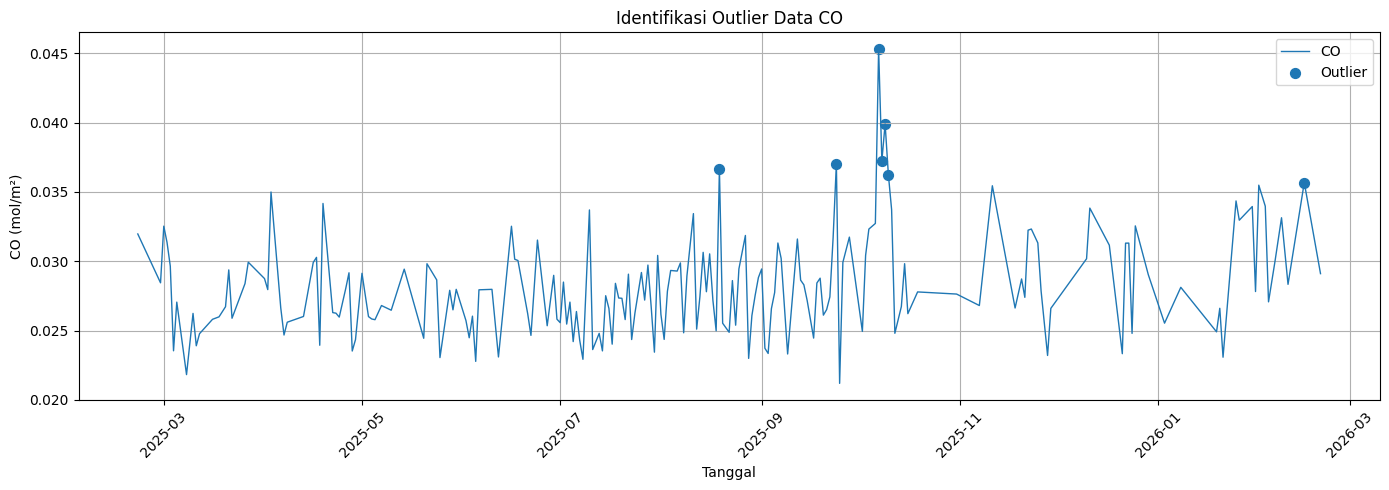

In [10]:
# ============================================================
# VISUALISASI OUTLIER
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    pd.to_datetime(df_365["tanggal"]),
    df_365["CO"],
    linewidth=1,
    label="CO"
)

plt.scatter(
    pd.to_datetime(
        df_365.loc[df_365["outlier"], "tanggal"]
    ),
    df_365.loc[df_365["outlier"], "CO"],
    marker="o",
    s=50,
    label="Outlier"
)

plt.title("Identifikasi Outlier Data CO")
plt.xlabel("Tanggal")
plt.ylabel("CO (mol/m²)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# PERBAIKAN OUTLIER
# ============================================================

# Simpan nilai sebelum diperbaiki
df_365["CO_sebelum_perbaikan"] = df_365["CO"]

# Ubah outlier menjadi NaN
df_365.loc[df_365["outlier"], "CO"] = np.nan

# Interpolasi nilai outlier
df_365["CO"] = df_365["CO"].interpolate(
    method="linear"
)

# Pengaman apabila ada NaN di ujung
df_365["CO"] = df_365["CO"].ffill().bfill()

print("Jumlah outlier yang diperbaiki :", jumlah_outlier)
print("Missing setelah perbaikan     :", df_365["CO"].isna().sum())

display(
    df_365.loc[
        df_365["outlier"],
        ["tanggal", "CO_sebelum_perbaikan", "CO"]
    ]
)

Jumlah outlier yang diperbaiki : 7
Missing setelah perbaikan     : 0


,tanggal,CO_sebelum_perbaikan,CO
179,2025-08-19,0.036652,0.025253
215,2025-09-24,0.037050,0.026449
228,2025-10-07,0.045314,0.032926
229,2025-10-08,0.037251,0.033124
230,2025-10-09,0.039908,0.033322
231,2025-10-10,0.036259,0.033521
360,2026-02-15,0.035680,0.034287


In [12]:
# ============================================================
# DATASET SETELAH PREPROCESSING
# ============================================================

df_final_co = df_365[
    ["tanggal", "CO"]
].copy()

df_final_co = df_final_co.sort_values(
    "tanggal"
).reset_index(drop=True)

print("Jumlah baris :", len(df_final_co))
print("Jumlah kolom :", len(df_final_co.columns))
print("Missing CO   :", df_final_co["CO"].isna().sum())

display(df_final_co.head(10))

Jumlah baris : 366
Jumlah kolom : 2
Missing CO   : 0


,tanggal,CO
0,2025-02-21,0.031969
1,2025-02-22,0.031465
2,2025-02-23,0.030961
3,2025-02-24,0.030458
4,2025-02-25,0.029954
5,2025-02-26,0.029450
6,2025-02-27,0.028947
7,2025-02-28,0.028443
8,2025-03-01,0.032531
9,2025-03-02,0.031356


In [13]:
# Simpan dataset hasil preprocessing
df_final_co.to_csv(
    "CO_365_hari_preprocessed.csv",
    index=False
)

print("Dataset berhasil disimpan sebagai:")
print("CO_365_hari_preprocessed.csv")

Dataset berhasil disimpan sebagai:
CO_365_hari_preprocessed.csv


In [14]:
# ============================================================
# INSTALL TSFEL
# ============================================================

!pip install -q tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.6 MB/s eta 0:00:00


##Ekstraksi Fitur TSFEL

In [15]:
# ============================================================
# EKSTRAKSI FITUR TSFEL
# ============================================================

import tsfel

# Pastikan data terurut
df_final_co = df_final_co.sort_values(
    "tanggal"
).reset_index(drop=True)

# Ambil sinyal CO
signal_co = df_final_co["CO"].to_numpy()

print("Jumlah data CO :", len(signal_co))
print("Missing value  :", np.isnan(signal_co).sum())

Jumlah data CO : 366
Missing value  : 0


In [16]:
# Konfigurasi fitur TSFEL
cfg = tsfel.get_features_by_domain()

print("Domain TSFEL:")

for domain, features in cfg.items():
    print(
        f"- {domain}: {len(features)} fitur"
    )

Domain TSFEL:
- spectral: 26 fitur
- statistical: 20 fitur
- temporal: 15 fitur
- fractal: 6 fitur


In [17]:
# ============================================================
# EKSTRAKSI FITUR
# ============================================================

features_co = tsfel.time_series_features_extractor(
    cfg,
    signal_co,
    verbose=0
)

print("Ekstraksi fitur selesai.")
print("Jumlah baris :", features_co.shape[0])
print("Jumlah fitur :", features_co.shape[1])

display(features_co)

Ekstraksi fitur selesai.
Jumlah baris : 1
Jumlah fitur : 156


/tmp/ipykernel_1355/320638609.py:5: UserWarning: Using default sampling frequency set in configuration file.
  features_co = tsfel.time_series_features_extractor(


,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,...,0_Wavelet variance_12.5Hz,0_Wavelet variance_2.78Hz,0_Wavelet variance_25.0Hz,0_Wavelet variance_3.12Hz,0_Wavelet variance_3.57Hz,0_Wavelet variance_4.17Hz,0_Wavelet variance_5.0Hz,0_Wavelet variance_6.25Hz,0_Wavelet variance_8.33Hz,0_Zero crossing rate
0,0.292569,0.102657,2.0,0.080156,1.889632,73.0,292.0,0.025809,0.030429,0.002732,...,0.000016,0.00016,0.000006,0.000133,0.000109,0.000088,0.000069,0.000049,0.00003,0.0


In [18]:
# ============================================================
# RINGKASAN DOMAIN FITUR
# ============================================================

print("Ringkasan domain TSFEL:")

for domain, features in cfg.items():
    print(
        f"{domain.capitalize():<12} : "
        f"{len(features)} konfigurasi fitur"
    )

Ringkasan domain TSFEL:
Spectral     : 26 konfigurasi fitur
Statistical  : 20 konfigurasi fitur
Temporal     : 15 konfigurasi fitur
Fractal      : 6 konfigurasi fitur


In [19]:
# ============================================================
# CONTOH PERHITUNGAN RMS
# ============================================================

X = np.array([2, -1, 3, -2, 4])

rms = np.sqrt(
    np.mean(X ** 2)
)

print("Data :", X)
print("RMS  :", rms)

Data : [ 2 -1  3 -2  4]
RMS  : 2.6076809620810595


In [20]:
# ============================================================
# CONTOH ZERO CROSSING RATE
# ============================================================

X = np.array([2, -1, 3, -2, 4])

zcr = np.sum(
    np.sign(X[:-1]) != np.sign(X[1:])
)

print("Data :", X)
print("Jumlah zero crossing :", zcr)

Data : [ 2 -1  3 -2  4]
Jumlah zero crossing : 4


In [21]:
# ============================================================
# CONTOH MEAN ABSOLUTE DIFFERENCE
# ============================================================

X = np.array([2, -1, 3, -2, 4])

mad = np.mean(
    np.abs(np.diff(X))
)

print("Data :", X)
print("Mean Absolute Difference :", mad)

Data : [ 2 -1  3 -2  4]
Mean Absolute Difference : 4.5


##Contoh Perhitungan Fitur

1 Root Mean Square (RMS)

Contoh data CO:
X = [2, -1, 3, -2, 4]

In [22]:
from IPython.display import display, Math

display(Math(r"RMS = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2}"))

<IPython.core.display.Math object>

2 Zero Crossing Rate (ZCR)

Contoh data:
X = [2, -1, 3, -2, 4]

Perubahan tanda:
2 → -1  = terjadi perubahan
-1 → 3  = terjadi perubahan
3 → -2  = terjadi perubahan
-2 → 4  = terjadi perubahan

Jumlah perubahan tanda = 4

Rumus:

In [23]:
display(Math(r"MAD = \frac{1}{N - 1} \sum_{i=1}^{N - 1} |x_{i+1} - x_i|"))

<IPython.core.display.Math object>

3 Mean Absolute Difference

Contoh data:
X = [2, 5, 1, 6, 0]

Perhitungan:

MAD = (|5-2| + |1-5| + |6-1| + |0-6|) / 4

MAD = (3 + 4 + 5 + 6) / 4

MAD = 18 / 4

MAD = 4.5

Interpretasi:
Nilai 4.5 menunjukkan rata-rata perubahan absolut antara data yang berurutan adalah 4.5


In [24]:
display(Math(r"H = -\sum_i p_i \log_2(p_i)"))

<IPython.core.display.Math object>

4 Spectral Entropy

Misalkan distribusi energi frekuensi yang telah dinormalisasi adalah:

p = [0.5, 0.25, 0.25]


Perhitungan:
H = -(0.5 log2(0.5) + 0.25 log2(0.25) + 0.25 log2(0.25))

H = -(0.5(-1) + 0.25(-2) + 0.25(-2))

H = -(-0.5 - 0.5 - 0.5)

H = 1.5 bit

Interpretasi:
Spectral Entropy sebesar 1.5 bit menunjukkan bagaimana energi sinyal tersebar pada beberapa komponen frekuensi.

Rumus:


In [25]:
display(Math(r"SC = \frac{\sum_k f_k A_k}{\sum_k A_k}"))


<IPython.core.display.Math object>

5 Spectral Centroid

Contoh:

Frekuensi:
f = [1, 2, 3] Hz

Amplitudo:
A = [2, 3, 1]

Rumus:

Perhitungan:
SC = ((1×2) + (2×3) + (3×1)) / (2 + 3 + 1)

SC = (2 + 6 + 3) / 6

SC = 11 / 6

SC = 1.83 Hz

Interpretasi:
Spectral Centroid sebesar 1.83 Hz menunjukkan titik pusat distribusi energi pada spektrum frekuensi.


Rumus:


In [26]:
display(Math(r"Spread = \sqrt{\frac{\sum_k A_k (f_k - SC)^2}{\sum_k A_k}}"))


<IPython.core.display.Math object>

6 Spectral Spread

Definisi:
Spectral Spread menunjukkan seberapa luas penyebaran energi frekuensi di sekitar Spectral Centroid.

Cara kerja:
Nilai setiap frekuensi dibandingkan dengan Spectral Centroid. Semakin besar penyebaran frekuensi, semakin besar nilai Spectral Spread.

Interpretasi:
Spectral Spread digunakan untuk mengetahui apakah energi sinyal terkonsentrasi pada rentang frekuensi tertentu atau tersebar pada rentang yang lebih luas.

In [27]:
display(Math(r"X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2 \pi k n / N}"))

<IPython.core.display.Math object>

##HASIL AKHIR

In [28]:
# ============================================================
# HASIL AKHIR FITUR
# ============================================================

features_co_final = features_co.copy()

print("Dataset fitur akhir")
print("-------------------")
print("Jumlah baris :", features_co_final.shape[0])
print("Jumlah fitur :", features_co_final.shape[1])

# Membuat tabel fitur ke bawah
tabel_fitur = pd.DataFrame({
    "No": range(1, len(features_co_final.columns) + 1),
    "Nama Fitur": features_co_final.columns,
    "Nilai": features_co_final.iloc[0].values
})

display(tabel_fitur)

Dataset fitur akhir
-------------------
Jumlah baris : 1
Jumlah fitur : 156


,No,Nama Fitur,Nilai
0,1,0_Absolute energy,0.292569
1,2,0_Area under the curve,0.102657
2,3,0_Autocorrelation,2.000000
3,4,0_Average power,0.080156
4,5,0_Centroid,1.889632
...,...,...,...
151,152,0_Wavelet variance_4.17Hz,0.000088
152,153,0_Wavelet variance_5.0Hz,0.000069
153,154,0_Wavelet variance_6.25Hz,0.000049
154,155,0_Wavelet variance_8.33Hz,0.000030


In [29]:
# Simpan hasil fitur ke CSV

features_co_final.to_csv(
    "fitur_TSFEL_CO.csv",
    index=False
)

print("File berhasil disimpan:")
print("fitur_TSFEL_CO.csv")

File berhasil disimpan:
fitur_TSFEL_CO.csv
